# 프로젝트 1: 생산관리 - OEE & 생산 효율 분석

## 프로젝트 배경

당신은 **한국정밀산업(주)** 스마트팩토리팀의 데이터 분석가입니다.  
공장에는 **3개 라인(A·B·C)**, 총 **12대의 가공설비**가 가동 중이며, **6종의 제품**을 생산합니다.

최근 경영진으로부터 다음과 같은 요청이 내려왔습니다:

> *"우리 공장 설비들의 종합효율(OEE)을 체계적으로 분석해 주세요.  
> 어떤 라인, 어떤 설비에서 로스가 가장 크고,  
> 개선 활동(3월 시작) 이후 실제로 효과가 있었는지 데이터로 보여주세요."*

### 분석 목표
1. **데이터 품질 확인** - 현장 데이터의 결측치·이상치를 파악하고 전처리
2. **OEE 산출** - 가동률 × 성능률 × 양품률을 설비·라인·기간별로 계산
3. **Six Big Losses 분석** - 비가동 유형별 로스를 정량화
4. **개선 효과 검증** - 3월 전/후 OEE 변화를 통계적으로 비교
5. **경영진 보고용 대시보드** - 핵심 KPI를 한눈에 보여주는 시각화

### 데이터 설명

| 파일 | 설명 | 주요 컬럼 |
|------|------|----------|
| `p1_equipment.csv` | 설비 마스터 (13대) | equipment_id, line, equipment_type, rated_capacity_per_hour |
| `p1_product.csv` | 제품 마스터 (6종) | product_code, standard_cycle_time_sec, target_defect_rate_pct |
| `p1_production_log.csv` | 일별 생산 실적 (~3,100건) | production_date, shift, actual_quantity, good_quantity, actual_operating_time_min |
| `p1_downtime_log.csv` | 비가동/로스 기록 (~430건) | downtime_type, duration_min, cause |

### OEE (Overall Equipment Effectiveness) 공식

```
OEE = 가동률(Availability) × 성능률(Performance) × 양품률(Quality)

가동률 = 실제가동시간 / 계획가동시간
성능률 = (실제생산량 × 기준사이클타임) / 실제가동시간
양품률 = 양품수량 / 실제생산량
```

---

## Part 0: 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 데이터 로드
equipment = pd.read_csv('../data/project1/p1_equipment.csv', encoding='utf-8-sig')
product = pd.read_csv('../data/project1/p1_product.csv', encoding='utf-8-sig')
prod_log = pd.read_csv('../data/project1/p1_production_log.csv', encoding='utf-8-sig')
downtime = pd.read_csv('../data/project1/p1_downtime_log.csv', encoding='utf-8-sig')

# 날짜 컬럼 변환
prod_log['production_date'] = pd.to_datetime(prod_log['production_date'])
downtime['date'] = pd.to_datetime(downtime['date'])
downtime['start_time'] = pd.to_datetime(downtime['start_time'])
downtime['end_time'] = pd.to_datetime(downtime['end_time'])

print('데이터 로드 완료!')
print(f'설비: {len(equipment)}건 | 제품: {len(product)}건 | 생산실적: {len(prod_log)}건 | 비가동: {len(downtime)}건')

데이터 로드 완료!
설비: 13건 | 제품: 6건 | 생산실적: 3120건 | 비가동: 427건


In [2]:
from koreanize_matplotlib import koreanize
koreanize()

---
## Part 1: 데이터 탐색 및 전처리 (25점)

현장에서 수집된 데이터는 **완벽하지 않습니다.**  
센서 오류, 기록 누락, 입력 실수 등으로 결측치와 이상치가 포함되어 있습니다.  
분석 전에 데이터 품질을 반드시 확인하고 전처리해야 합니다.

> **현업 포인트**: 데이터를 신뢰하지 마세요. 항상 먼저 확인하세요.

### 문제 1-1: 4개 데이터프레임 기본 탐색 (5점)

각 데이터프레임의 shape, dtypes, 처음 5행을 확인하세요.  
특히 **생산 실적(prod_log)**의 컬럼별 결측치 수와 비율을 확인하세요.

**확인할 것:**
- 어떤 컬럼에 결측치가 있는가?
- 결측치 비율이 분석에 영향을 줄 수준인가?

In [3]:
#unique()(nan도 포함됌), isna().sum(), nunique()<- unique 갯수 세는 것

In [4]:
product.head()

,product_code,product_name,standard_cycle_time_sec,category,weight_kg,target_defect_rate_pct
0,PRD-001,베어링하우징-S,30,하우징,2.5,1.5
1,PRD-002,베어링하우징-M,45,하우징,4.2,2.0
2,PRD-003,샤프트-A,25,샤프트,1.8,1.0
3,PRD-004,샤프트-B,35,샤프트,2.8,2.5
4,PRD-005,기어박스커버,60,커버,5.5,3.0


In [5]:
prod_log.head(2)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,402.9,15.0,OP-009


In [6]:
equipment.head(2)

,equipment_id,equipment_name,line,equipment_type,manufacturer,install_date,rated_capacity_per_hour
0,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120
1,EQ-A02,CNC선반-A2,A라인,CNC선반,화낙,2018-06-20,120


In [7]:
downtime.head(2)

,downtime_id,date,equipment_id,shift,downtime_type,start_time,end_time,duration_min,cause,line
0,DT-00001,2024-01-01,EQ-A03,야간,소정지,2024-01-01 22:08:00,2024-01-01 22:18:00,10.0,NaN,A라인
1,DT-00002,2024-01-02,EQ-A01,주간,설비고장,2024-01-02 09:24:00,2024-01-02 11:43:00,139.0,스핀들 이상,A라인


In [8]:
prod_log.isna().sum()

log_id                         0
production_date                0
shift                          0
equipment_id                   0
product_code                   0
planned_quantity               0
actual_quantity                0
good_quantity                 84
defect_quantity                0
planned_time_min               0
actual_operating_time_min     66
setup_time_min               111
operator_id                    0
dtype: int64

In [9]:
product.isna().sum()

product_code               0
product_name               0
standard_cycle_time_sec    0
category                   0
weight_kg                  0
target_defect_rate_pct     0
dtype: int64

In [10]:
equipment.isna().sum()


equipment_id               0
equipment_name             0
line                       0
equipment_type             0
manufacturer               0
install_date               0
rated_capacity_per_hour    0
dtype: int64

In [11]:
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      5
cause            15
line              0
dtype: int64

In [12]:
## downtime과 prod_log에 결측치 확인

missing_count_prod = prod_log.isnull().sum()
missing_ratio_prod = prod_log.isnull().mean() * 100

missing_summary_prod = pd.DataFrame({
    '결측치 개수': missing_count_prod,
    '결측치 비율(%)': missing_ratio_prod
})

missing_summary_prod

,결측치 개수,결측치 비율(%)
log_id,0,0.000000
production_date,0,0.000000
shift,0,0.000000
equipment_id,0,0.000000
product_code,0,0.000000
planned_quantity,0,0.000000
actual_quantity,0,0.000000
good_quantity,84,2.692308
defect_quantity,0,0.000000
planned_time_min,0,0.000000


In [13]:
missing_count_downtime = downtime.isnull().sum()
missing_ratio_downtime = downtime.isnull().mean() * 100

missing_summary_downtime = pd.DataFrame({
    '결측치 개수': missing_count_downtime,
    '결측치 비율(%)': missing_ratio_downtime
})

missing_summary_downtime

,결측치 개수,결측치 비율(%)
downtime_id,0,0.000000
date,0,0.000000
equipment_id,0,0.000000
shift,0,0.000000
downtime_type,0,0.000000
start_time,0,0.000000
end_time,0,0.000000
duration_min,5,1.170960
cause,15,3.512881
line,0,0.000000


In [14]:
prod_log[prod_log['good_quantity'].isna()]

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id
6,LOG-00007,2024-01-01,주간,EQ-B04,PRD-006,1224,1217,NaN,5,480,434.4,15.0,OP-002
57,LOG-00058,2024-01-03,야간,EQ-A04,PRD-003,979,691,NaN,7,480,340.3,20.0,OP-005
72,LOG-00073,2024-01-04,주간,EQ-B04,PRD-003,979,1005,NaN,20,480,442.3,15.0,OP-010
134,LOG-00135,2024-01-08,야간,EQ-B01,PRD-003,979,1004,NaN,9,480,429.3,20.0,OP-018
193,LOG-00194,2024-01-11,주간,EQ-C01,PRD-003,979,944,NaN,14,480,436.5,15.0,OP-004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3042,LOG-03043,2024-06-25,야간,EQ-C03,PRD-004,699,702,NaN,20,480,415.2,15.0,OP-001
3059,LOG-03060,2024-06-26,야간,EQ-B01,PRD-002,544,488,NaN,6,480,375.6,30.0,OP-016
3070,LOG-03071,2024-06-27,주간,EQ-A04,PRD-006,1224,963,NaN,9,480,375.3,20.0,OP-012
3093,LOG-03094,2024-06-28,주간,EQ-C01,PRD-002,544,537,NaN,12,480,403.2,30.0,OP-011


### 문제 1-2: 생산 실적 결측치 처리 (5점)

생산 현장에서 `good_quantity`(양품수량)가 비어있는 건은 **품질 검사가 아직 완료되지 않은 것**입니다.  
이런 경우 현업에서는 보통 `actual_quantity - defect_quantity`로 추정합니다.

`setup_time_min`이 비어있는 건은 **교대 인수인계 시 기록 누락**입니다.  
해당 설비의 평균 셋업 시간으로 대체하세요.

`actual_operating_time_min`이 비어있는 건도 해당 설비의 평균값으로 대체하세요.

**처리 후 결측치가 0인지 확인하세요.**

In [15]:
# 여기에 코드 작성
prod_log['good_quantity']=prod_log['good_quantity'].fillna(prod_log['actual_quantity'] - prod_log['defect_quantity'])

In [16]:
prod_log[prod_log['good_quantity'].isna()]

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id


In [17]:
prod_log_summary=prod_log.groupby('equipment_id').agg({'setup_time_min':'mean',
                                      'actual_operating_time_min':'mean'})

In [18]:
prod_log_summary.columns

Index(['setup_time_min', 'actual_operating_time_min'], dtype='object')

In [19]:
prod_log_summary.columns=['셋업타임 평균','작업시간 평균']

In [20]:
prod_log_summary

,셋업타임 평균,작업시간 평균
equipment_id,,
EQ-A01,21.791339,377.886770
EQ-A02,21.726908,375.958167
EQ-A03,21.870079,335.101158
EQ-A04,20.943775,379.054510
EQ-B01,21.967871,420.780545
EQ-B02,21.686047,421.428626
EQ-B03,21.844262,421.161943
EQ-B04,20.957031,424.041379
EQ-C01,21.720000,399.244314


In [21]:
prod_log=pd.merge(prod_log,prod_log_summary,on='equipment_id',how='left')

In [22]:
prod_log.head(2)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,셋업타임 평균,작업시간 평균
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004,21.791339,377.886770
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,402.9,15.0,OP-009,21.726908,375.958167


In [23]:
prod_log['setup_time_min']=prod_log['setup_time_min'].fillna(prod_log_summary['셋업타임 평균'])
# transform 을 이용해서도 할 수 있다
# map으로도 할 수 있다.

# transform
# fillna(prod_log.groupby('equipment_id')['setup_time_min'].transform('mean'))

# map
# fillna(same_df['setup_time_min'].map(prod_mean))


In [24]:
prod_log[prod_log['setup_time_min'].isna()]

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,셋업타임 평균,작업시간 평균
15,LOG-00016,2024-01-01,야간,EQ-B01,PRD-002,544,521,513.0,8,480,430.0,NaN,OP-009,21.967871,420.780545
50,LOG-00051,2024-01-03,주간,EQ-C01,PRD-003,979,928,912.0,16,480,422.2,NaN,OP-018,21.720000,399.244314
115,LOG-00116,2024-01-06,주간,EQ-B03,PRD-004,699,669,660.0,9,480,411.8,NaN,OP-013,21.844262,421.161943
131,LOG-00132,2024-01-08,야간,EQ-A02,PRD-001,816,594,575.0,19,480,338.4,NaN,OP-013,21.726908,375.958167
154,LOG-00155,2024-01-09,야간,EQ-A02,PRD-001,816,725,713.0,12,480,402.4,NaN,OP-009,21.726908,375.958167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000,LOG-03001,2024-06-22,주간,EQ-C04,PRD-006,1224,1058,1057.0,1,480,352.9,NaN,OP-015,22.247899,399.167769
3006,LOG-03007,2024-06-24,주간,EQ-B02,PRD-001,816,824,823.0,1,480,450.2,NaN,OP-002,21.686047,421.428626
3030,LOG-03031,2024-06-25,주간,EQ-B03,PRD-004,699,771,761.0,10,480,450.2,NaN,OP-004,21.844262,421.161943
3052,LOG-03053,2024-06-26,주간,EQ-C02,PRD-002,544,525,515.0,10,480,412.5,NaN,OP-010,22.023810,401.707087


In [25]:
prod_log['actual_operating_time_min']=prod_log['actual_operating_time_min'].fillna(prod_log_summary['작업시간 평균'])

In [26]:
prod_log.head(10)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,셋업타임 평균,작업시간 평균
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004,21.791339,377.886770
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,402.9,15.0,OP-009,21.726908,375.958167
2,LOG-00003,2024-01-01,주간,EQ-A03,PRD-004,699,426,407.0,19,480,313.3,25.0,OP-008,21.870079,335.101158
3,LOG-00004,2024-01-01,주간,EQ-A04,PRD-003,979,745,732.0,13,480,363.1,40.0,OP-004,20.943775,379.054510
4,LOG-00005,2024-01-01,주간,EQ-B02,PRD-003,979,954,953.0,1,480,441.3,20.0,OP-018,21.686047,421.428626
5,LOG-00006,2024-01-01,주간,EQ-B03,PRD-004,699,674,662.0,12,480,416.3,30.0,OP-019,21.844262,421.161943
6,LOG-00007,2024-01-01,주간,EQ-B04,PRD-006,1224,1217,1212.0,5,480,434.4,15.0,OP-002,20.957031,424.041379
7,LOG-00008,2024-01-01,주간,EQ-C01,PRD-001,816,730,721.0,9,480,417.3,15.0,OP-003,21.720000,399.244314
8,LOG-00009,2024-01-01,주간,EQ-C02,PRD-001,816,784,771.0,13,480,407.1,30.0,OP-008,22.023810,401.707087
9,LOG-00010,2024-01-01,주간,EQ-C03,PRD-004,699,598,584.0,14,480,382.1,20.0,OP-018,22.324219,396.467323


### 문제 1-3: 이상치 탐지 (5점)

생산량이 비정상적으로 낮은 건이 있을 수 있습니다 (자재 문제, 긴급 정지 등).  
`actual_quantity` 컬럼에서 **IQR 방법**으로 이상치를 탐지하세요.

1. Q1, Q3, IQR을 계산하세요
2. 하한(Q1 - 1.5×IQR) 미만인 이상치를 찾으세요
3. 이상치가 몇 건인지, 어떤 설비에서 주로 발생하는지 확인하세요
4. 이상치에 `is_outlier` 플래그 컬럼을 추가하세요 (True/False)

> **현업 포인트**: 이상치를 무조건 제거하면 안 됩니다. 원인을 파악하고, 분석 목적에 따라 포함/제외를 결정합니다.

In [27]:
# 여기에 코드 작성
Q1 = prod_log['actual_quantity'].quantile(0.25)
Q2 = prod_log['actual_quantity'].quantile(0.50)  
Q3 = prod_log['actual_quantity'].quantile(0.75)
IQR=Q3-Q1
# descrive로 가져올 수도 있다.ㄷㄷ

In [28]:
IQR

np.float64(399.0)

In [29]:
Q2

np.float64(729.0)

In [30]:
Q1-IQR*1.5

np.float64(-95.5)

In [31]:
prod_log[(prod_log['actual_quantity']<Q1 )| (prod_log['actual_quantity']>Q3)].value_counts('equipment_id')

equipment_id
EQ-B04    248
EQ-A03    194
EQ-C04    179
EQ-C03    148
EQ-A04    132
EQ-B03    129
EQ-B01     93
EQ-A01     93
EQ-C01     87
EQ-A02     86
EQ-B02     84
EQ-C02     82
Name: count, dtype: int64

In [32]:
prod_log['is_outlier']=np.where((prod_log['actual_quantity']<Q1-IQR*1.5 )| (prod_log['actual_quantity']>Q3+IQR*1.5),'True','False')

In [33]:
prod_log

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,셋업타임 평균,작업시간 평균,is_outlier
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004,21.791339,377.886770,False
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,402.9,15.0,OP-009,21.726908,375.958167,False
2,LOG-00003,2024-01-01,주간,EQ-A03,PRD-004,699,426,407.0,19,480,313.3,25.0,OP-008,21.870079,335.101158,False
3,LOG-00004,2024-01-01,주간,EQ-A04,PRD-003,979,745,732.0,13,480,363.1,40.0,OP-004,20.943775,379.054510,False
4,LOG-00005,2024-01-01,주간,EQ-B02,PRD-003,979,954,953.0,1,480,441.3,20.0,OP-018,21.686047,421.428626,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,LOG-03116,2024-06-29,주간,EQ-B04,PRD-006,1224,1239,1234.0,5,480,428.2,15.0,OP-018,20.957031,424.041379,False
3116,LOG-03117,2024-06-29,주간,EQ-C01,PRD-002,544,462,454.0,8,480,390.8,20.0,OP-009,21.720000,399.244314,False
3117,LOG-03118,2024-06-29,주간,EQ-C02,PRD-001,816,843,831.0,12,480,450.2,25.0,OP-010,22.023810,401.707087,False
3118,LOG-03119,2024-06-29,주간,EQ-C03,PRD-004,699,708,691.0,17,480,440.2,30.0,OP-006,22.324219,396.467323,False


### 문제 1-4: 마스터 데이터 결합 (5점)

생산 실적에 **설비 정보**와 **제품 정보**를 결합하세요.

1. `prod_log`에 `equipment` 테이블의 `line`, `equipment_type`, `equipment_name`을 left join
2. 이어서 `product` 테이블의 `product_name`, `standard_cycle_time_sec`, `category`를 left join
3. 결합 후 행 수가 변하지 않았는지 확인하세요
4. 결합된 데이터프레임을 `df`로 저장하세요

In [34]:
# 여기에 코드 작성
prod_log.head(3)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,operator_id,셋업타임 평균,작업시간 평균,is_outlier
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,351.9,15.0,OP-004,21.791339,377.886770,False
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,402.9,15.0,OP-009,21.726908,375.958167,False
2,LOG-00003,2024-01-01,주간,EQ-A03,PRD-004,699,426,407.0,19,480,313.3,25.0,OP-008,21.870079,335.101158,False


In [35]:
equipment_summary=equipment[['equipment_id','line','equipment_type','equipment_name']]

In [36]:
prod_log=pd.merge(prod_log,equipment_summary,on='equipment_id',how='left')

In [37]:
product_summary=product[['product_code','product_name','standard_cycle_time_sec','category']]

In [38]:
prod_log=pd.merge(prod_log,product_summary,on='product_code',how='left')

In [39]:
prod_log.head(2)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,...,operator_id,셋업타임 평균,작업시간 평균,is_outlier,line,equipment_type,equipment_name,product_name,standard_cycle_time_sec,category
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,...,OP-004,21.791339,377.886770,False,A라인,CNC선반,CNC선반-A1,샤프트-A,25,샤프트
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,...,OP-009,21.726908,375.958167,False,A라인,CNC선반,CNC선반-A2,베어링하우징-S,30,하우징


### 문제 1-5: 분석용 파생 컬럼 생성 (5점)

OEE 분석을 위해 다음 파생 컬럼을 만드세요:

1. `month` - 생산월 (1~6)
2. `week` - 주차 (ISO 주차)
3. `weekday` - 요일명 (월요일~토요일)
4. `defect_rate` - 불량률 (%) = defect_quantity / actual_quantity × 100
5. `achievement_rate` - 계획 달성률 (%) = actual_quantity / planned_quantity × 100

각 컬럼의 기본 통계(describe)를 확인하세요.

In [40]:
# 여기에 코드 작성
prod_log.head(2)

,log_id,production_date,shift,equipment_id,product_code,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,...,operator_id,셋업타임 평균,작업시간 평균,is_outlier,line,equipment_type,equipment_name,product_name,standard_cycle_time_sec,category
0,LOG-00001,2024-01-01,주간,EQ-A01,PRD-003,979,753,743.0,10,480,...,OP-004,21.791339,377.886770,False,A라인,CNC선반,CNC선반-A1,샤프트-A,25,샤프트
1,LOG-00002,2024-01-01,주간,EQ-A02,PRD-001,816,690,680.0,10,480,...,OP-009,21.726908,375.958167,False,A라인,CNC선반,CNC선반-A2,베어링하우징-S,30,하우징


In [41]:
prod_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   log_id                     3120 non-null   object        
 1   production_date            3120 non-null   datetime64[ns]
 2   shift                      3120 non-null   object        
 3   equipment_id               3120 non-null   object        
 4   product_code               3120 non-null   object        
 5   planned_quantity           3120 non-null   int64         
 6   actual_quantity            3120 non-null   int64         
 7   good_quantity              3120 non-null   float64       
 8   defect_quantity            3120 non-null   int64         
 9   planned_time_min           3120 non-null   int64         
 10  actual_operating_time_min  3054 non-null   float64       
 11  setup_time_min             3009 non-null   float64       
 12  operat

In [42]:
prod_log['month']=prod_log['production_date'].dt.to_period('M')

In [43]:
prod_log['week']=prod_log['production_date'].dt.isocalendar()['week'].astype(int)

In [44]:
prod_log['weekday']=prod_log['production_date'].dt.day_name()

In [45]:
prod_log['defect_rate']=prod_log['defect_quantity']/prod_log['actual_quantity'] *100

In [46]:
prod_log['achievement_rate'] = prod_log['actual_quantity']/ prod_log['planned_quantity'] *100

In [47]:
prod_log.describe()

,production_date,planned_quantity,actual_quantity,good_quantity,defect_quantity,planned_time_min,actual_operating_time_min,setup_time_min,셋업타임 평균,작업시간 평균,standard_cycle_time_sec,week,defect_rate,achievement_rate
count,3120,3120.000000,3120.000000,3120.000000,3120.000000,3120.0,3054.000000,3009.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000
mean,2024-03-30 18:57:13.846153728,802.624038,716.694231,706.153526,10.540705,480.0,395.982777,21.756397,21.756508,395.931930,34.256410,13.504167,1.717231,88.988063
min,2024-01-01 00:00:00,408.000000,52.000000,49.000000,1.000000,480.0,265.100000,15.000000,20.943775,335.101158,20.000000,1.000000,0.074683,12.017167
25%,2024-02-15 00:00:00,544.000000,503.000000,493.000000,7.000000,480.0,373.425000,15.000000,21.686047,377.886770,25.000000,7.000000,0.972628,81.920327
50%,2024-04-01 00:00:00,816.000000,729.000000,718.000000,10.000000,480.0,398.200000,20.000000,21.791339,399.244314,30.000000,14.000000,1.537280,89.785495
75%,2024-05-15 00:00:00,979.000000,902.000000,892.000000,13.000000,480.0,421.300000,25.000000,21.967871,421.161943,45.000000,20.000000,2.321322,97.058824
max,2024-06-29 00:00:00,1224.000000,1380.000000,1377.000000,50.000000,480.0,460.200000,40.000000,22.324219,424.041379,60.000000,26.000000,8.896797,112.768131
std,NaN,252.454517,252.705636,253.058232,4.797230,0.0,35.458552,6.456494,0.409656,25.050632,12.590485,7.468088,1.019999,12.347651


---
## Part 2: OEE 산출 (25점)

**OEE(Overall Equipment Effectiveness, 설비종합효율)**은 제조업에서 가장 중요한 KPI 중 하나입니다.  
세계적 제조기업들의 OEE 벤치마크:

| 등급 | OEE | 의미 |
|------|-----|------|
| World Class | 85% 이상 | 글로벌 상위 |
| Good | 70~85% | 양호 |
| Average | 55~70% | 개선 필요 |
| Poor | 55% 미만 | 심각한 로스 |

> **왜 OEE인가?** 단순 가동률만 보면 '속도 로스'와 '품질 로스'를 놓칩니다.  
> OEE는 시간·속도·품질 세 관점을 곱해 **진짜 효율**을 보여줍니다.

### 문제 2-1: 건별 OEE 3요소 계산 (10점)

각 생산 실적 건(행)마다 OEE 3요소를 계산하세요.  
이상치(`is_outlier == True`)는 **제외**하고 계산하세요.

```
가동률(availability) = actual_operating_time_min / planned_time_min
성능률(performance) = (actual_quantity × standard_cycle_time_sec / 60) / actual_operating_time_min
양품률(quality)     = good_quantity / actual_quantity
OEE               = availability × performance × quality
```

1. 위 4개 컬럼을 `df`에 추가하세요 (소수점, 0~1 범위)
2. OEE의 기본 통계(describe)를 확인하세요
3. OEE가 1을 초과하는 건이 있는지 확인하고, 있다면 1로 클리핑하세요

> **주의**: 성능률이 1을 초과할 수 있습니다 (기준 사이클타임보다 빠르게 생산한 경우).  
> 현업에서는 보통 1.0으로 제한(clip)합니다.

In [48]:
# 여기에 코드 작성
prod_actual_oper_OK=(prod_log.loc[prod_log['is_outlier']=='False','actual_operating_time_min'])

In [49]:
prod_planned_time_OK=(prod_log.loc[prod_log['is_outlier']=='False','planned_time_min'])

In [50]:
prod_log['availability'] = None

In [51]:
prod_log.loc[prod_log['is_outlier']=='False','availability']=prod_actual_oper_OK/prod_planned_time_OK

In [52]:
prod_actual_quantity_OK=(prod_log.loc[prod_log['is_outlier']=='False','actual_quantity'])

In [53]:
prod_standard_cycle_time_sec_OK=(prod_log.loc[prod_log['is_outlier']=='False','standard_cycle_time_sec'])

In [54]:
prod_log['performance']=None

In [55]:
prod_log.loc[prod_log['is_outlier']=='False','performance']=(prod_actual_quantity_OK*prod_standard_cycle_time_sec_OK/60)/prod_actual_oper_OK

In [56]:
prod_log.loc[prod_log['performance']>1,'performance'] = 1

In [57]:
prod_good_quantity_OK=(prod_log.loc[prod_log['is_outlier']=='False','good_quantity'])

In [58]:
prod_log.loc[prod_log['is_outlier']=='False','quality']=prod_good_quantity_OK/prod_actual_quantity_OK

In [59]:
prod_log.loc[prod_log['is_outlier']=='False','OEE']=prod_log['quality']*prod_log['performance']*prod_log['availability']

In [60]:
prod_log['OEE'].mean()

np.float64(0.7440543483282173)

### 문제 2-2: 설비별 OEE 집계 (5점)

설비별(equipment_id) 평균 OEE와 3요소를 집계하세요.

1. 설비별 평균 `availability`, `performance`, `quality`, `oee`를 계산
2. OEE 기준 내림차순 정렬
3. 결과에 `equipment_name`과 `line`을 포함
4. OEE가 가장 낮은 설비 3대는 어디인가?
5. 어떤 요소(가동률/성능률/양품률)가 OEE를 끌어내리고 있는가?

In [61]:
# 여기에 코드 작성
equipment_OEE=prod_log.groupby('equipment_id').agg({'availability':'mean',
                                      'performance':'mean',
                                      'quality':'mean',
                                      'OEE':'mean'}).sort_values('OEE',ascending=False)

In [62]:
prod_info = (
    prod_log
    .groupby('equipment_id')[['equipment_name','line']]
    .first()
    .reset_index()
)


In [63]:
#pd.merge(equipment_OEE,prod_log[['equipment_id','equipment_name','line']],on='equipment_id',how='left')
# 내가 원하는 컬럼만 붙일 수 있다
pd.merge(equipment_OEE,prod_info,on='equipment_id',how='left')

,equipment_id,availability,performance,quality,OEE,equipment_name,line
0,EQ-B02,0.877976,0.952396,0.989244,0.8274,CNC선반-B2,B라인
1,EQ-B04,0.88342,0.941311,0.992040,0.825046,드릴프레스-B4,B라인
2,EQ-B01,0.876626,0.949256,0.988051,0.822355,CNC선반-B1,B라인
3,EQ-B03,0.877421,0.953664,0.979067,0.819432,밀링머신-B3,B라인
4,EQ-C02,0.83689,0.913282,0.985817,0.753798,CNC선반-C2,C라인
5,EQ-C01,0.831759,0.916553,0.985037,0.750914,CNC선반-C1,C라인
6,EQ-C04,0.8316,0.911705,0.989775,0.750488,드릴프레스-C4,C라인
7,EQ-C03,0.825974,0.916041,0.972363,0.735935,밀링머신-C3,C라인
8,EQ-A04,0.789697,0.88787,0.987322,0.692648,드릴프레스-A4,A라인
9,EQ-A01,0.787264,0.879756,0.980208,0.679207,CNC선반-A1,A라인


In [64]:
#제일낮은 설비 3대 : EQ-A01,EQ-A02,EQ-A03
# OEE악화시키는 요소 -> availability

### 문제 2-3: 라인별·월별 OEE 추이 (10점)

경영진은 **3월에 시작한 설비 개선 활동**의 효과를 확인하고 싶어합니다.

1. 라인별(A/B/C) + 월별 평균 OEE를 피벗 테이블로 만드세요  
   - index='line', columns='month', values='oee'
2. 해당 피벗 테이블을 **히트맵**으로 시각화하세요
   - `annot=True, fmt='.1%'` (퍼센트 포맷)
   - `cmap='RdYlGn'` (빨강→노랑→녹색)
3. 전체 월별 OEE 추이를 **라인 차트**로 그리세요
   - 라인별 색상 구분
   - 3월에 세로 점선 추가 (`axvline`)하여 '개선 활동 시작' 표시
4. 개선 전(1~3월)과 개선 후(4~6월) 평균 OEE를 비교하는 표를 출력하세요

In [65]:
# 여기에 코드 작성
l_m_pivot=pd.pivot_table(prod_log,index='line',columns='month',values='OEE',aggfunc='mean')

In [66]:
l_m_pivot.dtypes

month
2024-01    object
2024-02    object
2024-03    object
2024-04    object
2024-05    object
2024-06    object
Freq: M, dtype: object

In [67]:
l_m_pivot = l_m_pivot.apply(
    pd.to_numeric,
    errors='coerce'
)

<Axes: xlabel='month', ylabel='line'>

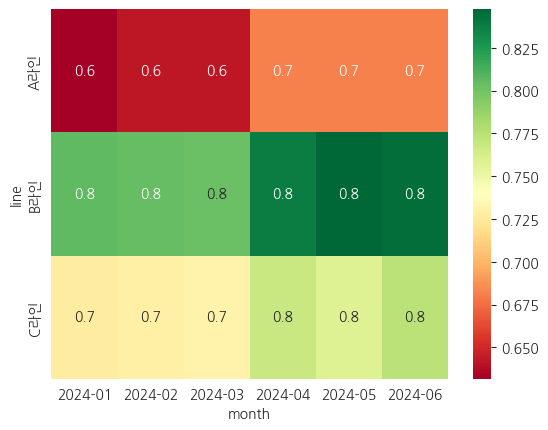

In [68]:
sns.heatmap(data=l_m_pivot,annot=True, fmt='.1f', cmap= 'RdYlGn')

In [69]:
chart_month=prod_log.groupby('month')['OEE'].mean()

In [70]:
chart_month.index = chart_month.index.astype(str)

In [71]:
l_m_pivot

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
line,,,,,,
A라인,0.631650,0.642306,0.642249,0.681941,0.682249,0.682110
B라인,0.805761,0.803744,0.802412,0.837847,0.847555,0.844226
C라인,0.727562,0.729165,0.731021,0.768113,0.757629,0.773616


Text(2024-03, 0.8583501356402994, '개선 활동 시작')

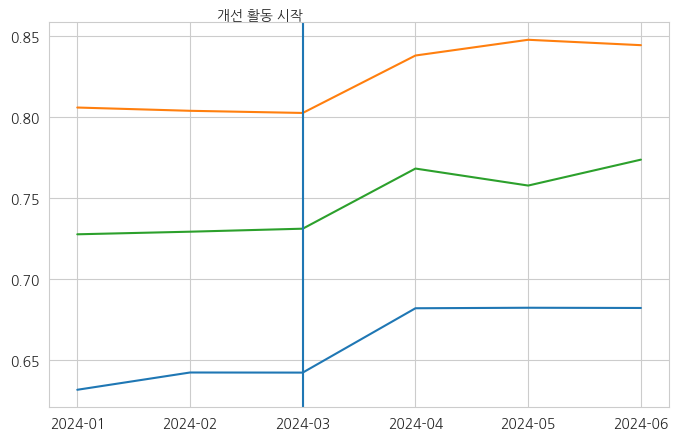

In [72]:
plt.figure(figsize=(8,5))
plt.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['A라인',:],)
plt.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['B라인',:],)
plt.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['C라인',:],)
plt.axvline(x='2024-03')
plt.text(
    '2024-03',
    plt.ylim()[1],
    '개선 활동 시작',
    rotation=0,
    va='bottom',
    ha='right'
)


---
## Part 3: 심화 분석 (20점)

OEE 숫자만으로는 부족합니다.  
경영진과 현장 관리자가 **구체적인 액션**을 취하려면,  
교대조·제품·설비 유형별로 **어디서, 왜** 로스가 발생하는지 알아야 합니다.

### 문제 3-1: 교대조별 OEE 비교 (5점)

야간 근무는 주간보다 품질이 떨어진다는 현장의 목소리가 있습니다.  
데이터로 확인해 보세요.

1. 교대조별(주간/야간) OEE 3요소 + OEE 평균을 비교표로 출력
2. **박스플롯**으로 교대조별 OEE 분포를 비교하세요
   - 같은 Figure에 OEE, 가동률, 성능률, 양품률 4개 subplot (2×2)
3. 주간 vs 야간 차이가 통계적으로 유의한지 **t-test**를 수행하세요
   - `from scipy import stats`
   - p-value < 0.05이면 유의한 차이

In [73]:
# 여기에 코드 작성
shift_OEE=prod_log.groupby('shift').agg({'availability':'mean',
                                      'performance':'mean',
                                      'quality':'mean',
                                      'OEE':'mean'}).sort_values('OEE',ascending=False)

In [74]:
shift_OEE

,availability,performance,quality,OEE
shift,,,,
주간,0.832789,0.91571,0.984000,0.752027
야간,0.815585,0.914901,0.981417,0.734497


<Axes: xlabel='shift', ylabel='availability'>

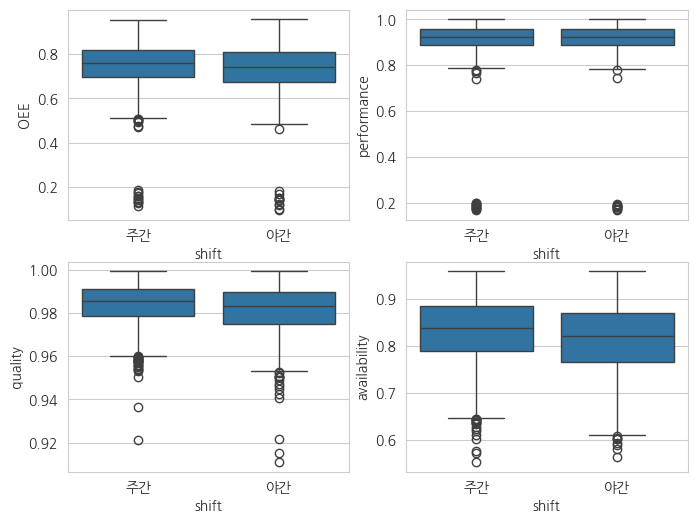

In [75]:
plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
sns.boxplot(data=prod_log,x='shift',y='OEE' )

plt.subplot(2,2,2)
sns.boxplot(data=prod_log,x='shift',y='performance' )

plt.subplot(2,2,3)
sns.boxplot(data=prod_log,x='shift',y='quality' )

plt.subplot(2,2,4)
sns.boxplot(data=,x='shift',y='availability' )


### 문제 3-2: 설비-제품 매트릭스 분석 (5점)

모든 설비가 모든 제품을 동일하게 잘 만드는 것은 아닙니다.  
**어떤 설비에서 어떤 제품을 만들 때 OEE가 높은지** 매트릭스로 분석하세요.

1. `equipment_id`(행) × `product_code`(열)의 평균 OEE 피벗 테이블
2. **히트맵**으로 시각화 (annot=True, fmt='.1%', cmap='YlGnBu')
3. 가장 OEE가 높은 설비-제품 조합 Top 5, 가장 낮은 조합 Bottom 5를 출력하세요

In [76]:
# 여기에 코드 작성
equip_prod_table=pd.pivot_table(prod_log,index='equipment_id',columns='product_code',values='OEE',aggfunc='mean')


In [77]:
equip_prod_table=equip_prod_table.fillna(0)

<Axes: xlabel='product_code', ylabel='equipment_id'>

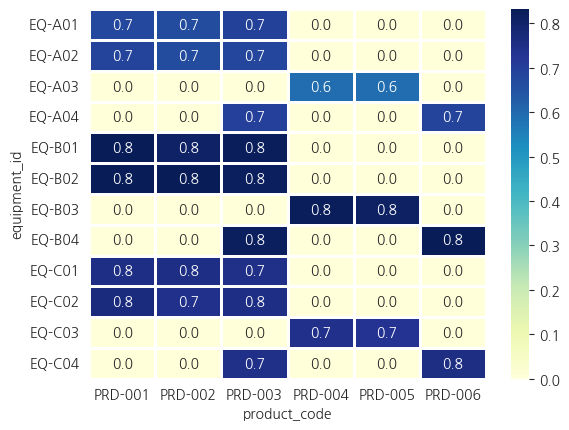

In [78]:
sns.heatmap(data=equip_prod_table, cmap='YlGnBu', linewidths=0.9,
           annot= True, fmt='.1f')

In [79]:
# oee효율이 좋은 장비 top 1 : eq-b002,[prd-001,prd-002]
# oee효율이 안 좋은 장비 top1 : eq-a003,prd-004

In [80]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [81]:
from scipy import stats

# (필요하면 숫자 변환)
prod_log['OEE'] = pd.to_numeric(prod_log['OEE'], errors='coerce')

# 주간 vs 야간 t-test
t_stat, p_value = stats.ttest_ind(
    prod_log.loc[prod_log['shift'] == '주간', 'OEE'],
    prod_log.loc[prod_log['shift'] == '야간', 'OEE'],
    equal_var=False,      # Welch t-test (실무 추천)
    nan_policy='omit'     # NaN 제거
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# 유의성 판단
if p_value < 0.05:
    print("→ 주간과 야간은 통계적으로 유의한 차이가 있습니다.")
else:
    print("→ 통계적으로 유의한 차이가 있다고 보기 어렵습니다.")


t-statistic: 4.560468596884662
p-value: 5.315045194761331e-06
→ 주간과 야간은 통계적으로 유의한 차이가 있습니다.


### 문제 3-3: 요일별 생산성 패턴 분석 (5점)

월요일 아침에는 설비 워밍업이 필요하고, 금요일 오후에는 피로도가 높다는 가설이 있습니다.

1. 요일별 평균 OEE와 불량률을 집계하세요 (월~토)
2. **이중 y축 차트**로 시각화하세요
   - 왼쪽 y축: 평균 OEE (bar 차트)
   - 오른쪽 y축: 평균 불량률 (line 차트, 빨간색)
3. 어떤 요일에 생산성이 가장 좋고, 가장 나쁜가?

In [82]:
# 여기에 코드 작성
shift_weekday=prod_log.groupby('weekday').agg({'defect_rate':'mean',
                                      'OEE':'mean'}).sort_values('OEE')

In [83]:
shift_weekday

,defect_rate,OEE
weekday,,
Tuesday,1.739215,0.740954
Monday,1.700017,0.741915
Thursday,1.728396,0.742360
Friday,1.747421,0.743164
Wednesday,1.756246,0.745564
Saturday,1.539868,0.757179


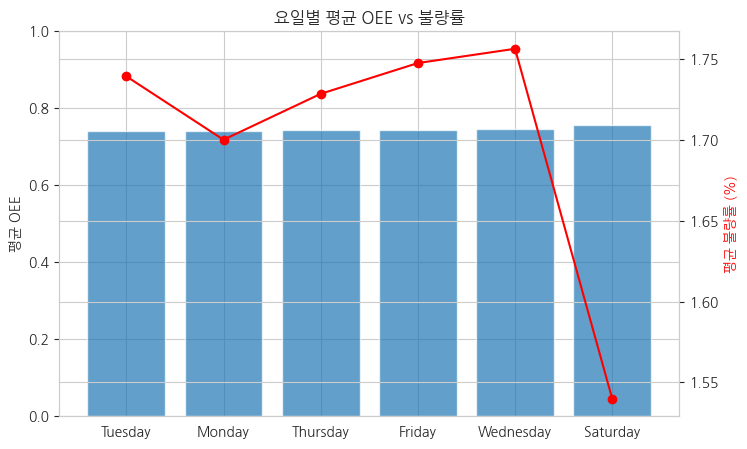

In [84]:

fig, ax1 = plt.subplots(figsize=(8,5))

# 왼쪽 y축 → 평균 OEE (bar)
ax1.bar(
    shift_weekday.index,
    shift_weekday['OEE'],
    alpha=0.7
)
ax1.set_ylabel('평균 OEE')
ax1.set_ylim(0, 1)

# 오른쪽 y축 → 평균 불량률 (line)
ax2 = ax1.twinx()

ax2.plot(
    shift_weekday.index,
    shift_weekday['defect_rate'],
    color='red',
    marker='o'
)
ax2.set_ylabel('평균 불량률 (%)', color='red')

plt.title('요일별 평균 OEE vs 불량률')
plt.show()


In [85]:
#일요일이 가장 생산성이 좋고, 수요일이 가장 안 좋다

### 문제 3-4: 계획 달성률 vs 불량률 관계 분석 (5점)

"무리하게 생산량을 맞추면 불량이 늘어난다"는 현장의 우려가 있습니다.

1. `achievement_rate`(계획달성률)와 `defect_rate`(불량률)의 **산점도**를 그리세요
   - 라인별 색상 구분 (hue='line')
   - 추세선 포함 (sns.regplot 또는 sns.lmplot)
2. 두 변수의 **상관계수**를 라인별로 계산하세요
3. 달성률 100% 이상인 그룹과 미만인 그룹의 평균 불량률을 비교하세요

<Axes: xlabel='achievement_rate', ylabel='defect_rate'>

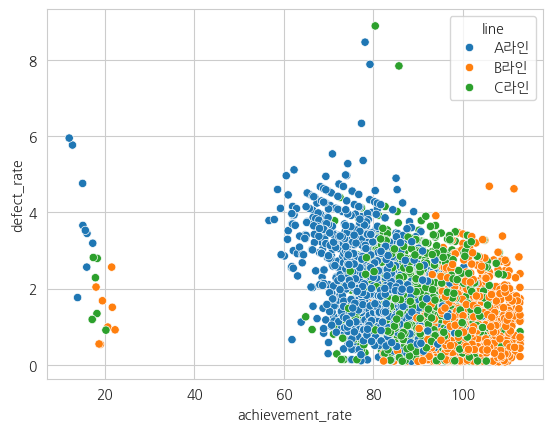

In [86]:
# 여기에 코드 작성
sns.scatterplot(data=prod_log, x=prod_log['achievement_rate'] , y=prod_log['defect_rate'] ,hue = 'line')

In [87]:
prod_log.groupby('line')

In [88]:
prod_log.groupby('line')[['achievement_rate','defect_rate']].corr()

achievement_rate  defect_rate
line                                                
A라인  achievement_rate          1.000000    -0.417206
     defect_rate              -0.417206     1.000000
B라인  achievement_rate          1.000000     0.000830
     defect_rate               0.000830     1.000000
C라인  achievement_rate          1.000000    -0.070206
     defect_rate              -0.070206     1.000000

In [89]:
prod_log[prod_log['achievement_rate']>=100]['defect_rate'].mean()

np.float64(1.360552330381069)

In [90]:
prod_log[prod_log['achievement_rate']<100]['defect_rate'].mean()

np.float64(1.7930586133514552)

---
## Part 4: Six Big Losses 분석 (15점)

TPM(Total Productive Maintenance)에서는 설비 효율을 떨어뜨리는 원인을  
**6대 로스(Six Big Losses)**로 분류합니다:

| 분류 | 로스 유형 | OEE 영향 |
|------|----------|----------|
| 정지 로스 | ① 설비고장, ② 셋업/조정 | 가동률 ↓ |
| 속도 로스 | ③ 소정지, ④ 속도저하 | 성능률 ↓ |
| 불량 로스 | ⑤ 초기불량, ⑥ 공정불량 | 양품률 ↓ |

비가동 데이터(`downtime`)를 활용하여 로스를 분석합니다.

### 문제 4-1: 비가동 유형별 분석 (5점)

1. `downtime` 데이터의 결측치를 처리하세요
   - `duration_min` 결측: 같은 `downtime_type`의 평균값으로 대체
   - `cause` 결측: '원인미상'으로 대체
2. 비가동 유형별 **건수**, **총 시간(분)**, **평균 시간(분)**을 집계하세요
3. **파레토 차트**를 그리세요
   - 막대: 유형별 총 비가동 시간 (내림차순)
   - 선: 누적 비율(%)

In [91]:
# 여기에 코드 작성
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      5
cause            15
line              0
dtype: int64

In [92]:
downtime['duration_min']=downtime['duration_min'].fillna(downtime.groupby('downtime_type')['duration_min'].transform('mean'))

In [93]:
downtime.isna().sum()

downtime_id       0
date              0
equipment_id      0
shift             0
downtime_type     0
start_time        0
end_time          0
duration_min      0
cause            15
line              0
dtype: int64

In [94]:
downtime['cause'].fillna('원인미상', inplace= True)

In [95]:
downtime.isna().sum()

downtime_id      0
date             0
equipment_id     0
shift            0
downtime_type    0
start_time       0
end_time         0
duration_min     0
cause            0
line             0
dtype: int64

In [96]:
downtime.head(2)

,downtime_id,date,equipment_id,shift,downtime_type,start_time,end_time,duration_min,cause,line
0,DT-00001,2024-01-01,EQ-A03,야간,소정지,2024-01-01 22:08:00,2024-01-01 22:18:00,10.0,원인미상,A라인
1,DT-00002,2024-01-02,EQ-A01,주간,설비고장,2024-01-02 09:24:00,2024-01-02 11:43:00,139.0,스핀들 이상,A라인


In [97]:
downtime_summary=downtime.groupby('downtime_type').agg({'downtime_id':'count',
                                       'duration_min': ['sum','mean']})

In [98]:
downtime_summary.head(2)

downtime_id  duration_min            
                    count           sum        mean
downtime_type                                      
계획정지                   47   3887.717391   82.717391
설비고장                  115  15182.017544  132.017544

In [99]:
downtime_summary.columns=['건수','총 시간(분)','평균 시간(분)']

In [100]:
downtime_summary.head(2)

,건수,총 시간(분),평균 시간(분)
downtime_type,,,
계획정지,47,3887.717391,82.717391
설비고장,115,15182.017544,132.017544


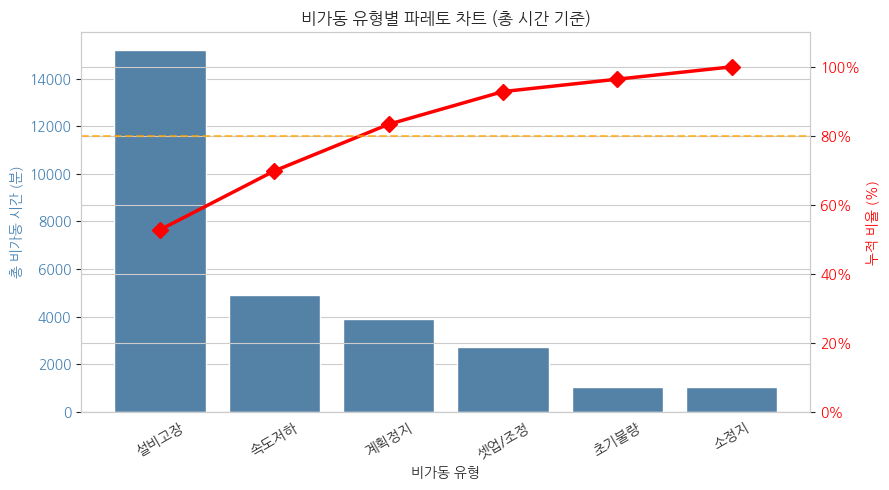

  downtime_type  총 시간(분)  누적비율(%)
1          설비고장  15182.0     52.8
4          속도저하   4906.1     69.8
0          계획정지   3887.7     83.4
2         셋업/조정   2726.0     92.8
5          초기불량   1033.4     96.4
3           소정지   1030.0    100.0


In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1) 컬럼명 변경 (당신의 코드 적용)


# 2) 'downtime_type' 컬럼이 index에 있으므로 reset_index
downtime_summary = downtime_summary.reset_index()
downtime_summary.rename(columns={'index':'downtime_type'}, inplace=True)

# 3) 총 시간(분) 기준 내림차순 정렬
downtime_summary = downtime_summary.sort_values('총 시간(분)', ascending=False)

# 4) 누적합, 누적 비율 계산
downtime_summary['누적시간'] = downtime_summary['총 시간(분)'].cumsum()
downtime_summary['누적비율(%)'] = downtime_summary['누적시간'] / downtime_summary['총 시간(분)'].sum() * 100

# 5) 파레토 차트 그리기
fig, ax1 = plt.subplots(figsize=(9, 5))

# 막대: 총 시간(분)
sns.barplot(data=downtime_summary, x='downtime_type', y='총 시간(분)', 
            color='steelblue', ax=ax1)
ax1.set_xlabel('비가동 유형')
ax1.set_ylabel('총 비가동 시간 (분)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=30)

# 선: 누적 비율(%)
ax2 = ax1.twinx()
ax2.plot(downtime_summary['downtime_type'], downtime_summary['누적비율(%)'], 
         color='red', marker='D', linewidth=2.5, markersize=8)
ax2.set_ylabel('누적 비율 (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim(0, 110)

# 80% 기준선
ax2.axhline(y=80, color='orange', linestyle='--', alpha=0.7)

plt.title('비가동 유형별 파레토 차트 (총 시간 기준)')
plt.tight_layout()
plt.show()

# 결과표 출력
print(downtime_summary[['downtime_type', '총 시간(분)', '누적비율(%)']].round(1))


### 문제 4-2: 설비별 비가동 패턴 분석 (5점)

어떤 설비에서 어떤 유형의 로스가 집중되는지 파악합니다.

1. `equipment_id`(행) × `downtime_type`(열)의 총 비가동 시간 피벗 테이블
2. **스택 바 차트**로 시각화하세요
   - 설비별 누적 막대그래프
   - 각 유형별 색상 구분
3. 비가동 시간이 가장 긴 설비 Top 3는? 주로 어떤 유형인가?
4. 비가동 기록이 없는 설비가 있는지 확인하세요 (equipment 테이블과 left join)

In [102]:
downtime.head(2)

,downtime_id,date,equipment_id,shift,downtime_type,start_time,end_time,duration_min,cause,line
0,DT-00001,2024-01-01,EQ-A03,야간,소정지,2024-01-01 22:08:00,2024-01-01 22:18:00,10.0,원인미상,A라인
1,DT-00002,2024-01-02,EQ-A01,주간,설비고장,2024-01-02 09:24:00,2024-01-02 11:43:00,139.0,스핀들 이상,A라인


In [103]:
downtime_summary1=downtime.groupby(['equipment_id','downtime_type']).agg({'duration_min':'sum'})

In [104]:
downtime_summary1.reset_index(inplace=True)

In [105]:
downtime_summary1

,equipment_id,downtime_type,duration_min
0,EQ-A01,계획정지,643.0
1,EQ-A01,설비고장,1809.0
2,EQ-A01,셋업/조정,321.0
3,EQ-A01,소정지,124.0
4,EQ-A01,속도저하,528.0
...,...,...,...
67,EQ-C04,설비고장,391.0
68,EQ-C04,셋업/조정,146.0
69,EQ-C04,소정지,54.0
70,EQ-C04,속도저하,440.0


In [106]:
downtime_summary1.rename(columns={'duration_min':'총 비가동시간'},inplace=True)

In [107]:
pivot_downtime=pd.pivot_table(downtime_summary1,index='equipment_id',columns='downtime_type',values='총 비가동시간',aggfunc='sum')

In [108]:
prod_log.columns

Index(['log_id', 'production_date', 'shift', 'equipment_id', 'product_code',
       'planned_quantity', 'actual_quantity', 'good_quantity',
       'defect_quantity', 'planned_time_min', 'actual_operating_time_min',
       'setup_time_min', 'operator_id', '셋업타임 평균', '작업시간 평균', 'is_outlier',
       'line', 'equipment_type', 'equipment_name', 'product_name',
       'standard_cycle_time_sec', 'category', 'month', 'week', 'weekday',
       'defect_rate', 'achievement_rate', 'availability', 'performance',
       'quality', 'OEE'],
      dtype='object')

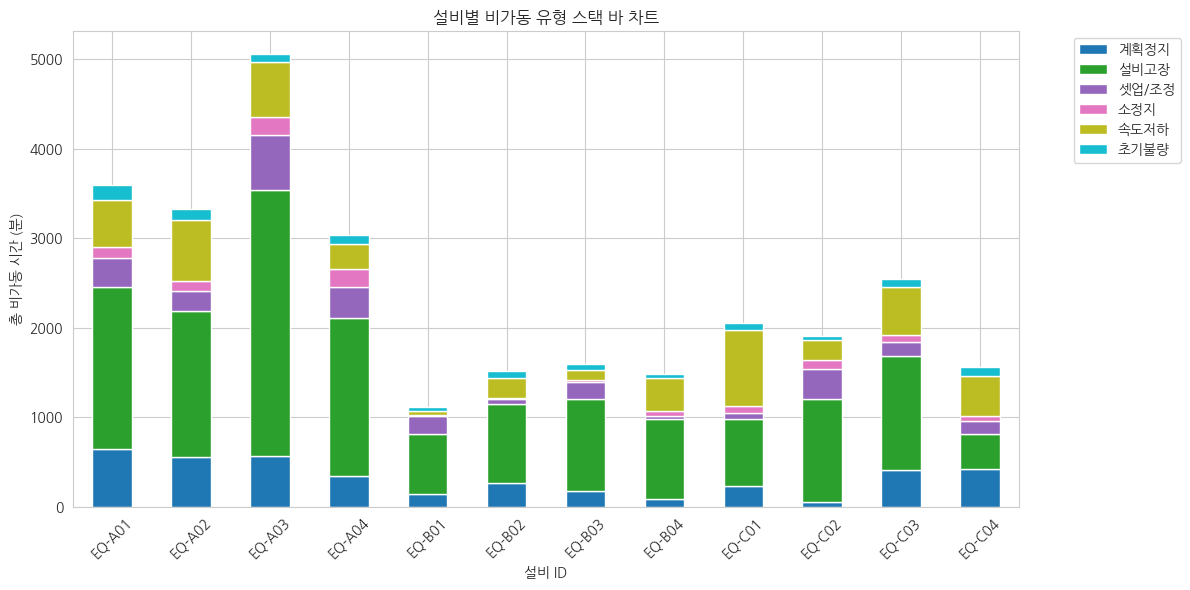

In [109]:
# 1줄로 끝!
pivot_downtime.plot(kind='bar', stacked=True, figsize=(12, 6),
                colormap='tab10', edgecolor='white', linewidth=1)

plt.xlabel('설비 ID')
plt.ylabel('총 비가동 시간 (분)')
plt.title('설비별 비가동 유형 스택 바 차트')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# DF에 바로 하는 방식

In [112]:
equipment

,equipment_id,equipment_name,line,equipment_type,manufacturer,install_date,rated_capacity_per_hour
0,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120
1,EQ-A02,CNC선반-A2,A라인,CNC선반,화낙,2018-06-20,120
2,EQ-A03,밀링머신-A3,A라인,밀링머신,DMG모리,2019-01-10,80
3,EQ-A04,드릴프레스-A4,A라인,드릴프레스,브라더,2019-04-05,150
4,EQ-B01,CNC선반-B1,B라인,CNC선반,화낙,2021-07-01,130
5,EQ-B02,CNC선반-B2,B라인,CNC선반,마작,2021-09-15,130
6,EQ-B03,밀링머신-B3,B라인,밀링머신,DMG모리,2022-02-10,90
7,EQ-B04,드릴프레스-B4,B라인,드릴프레스,브라더,2022-05-20,160
8,EQ-C01,CNC선반-C1,C라인,CNC선반,두산,2020-01-15,125
9,EQ-C02,CNC선반-C2,C라인,CNC선반,두산,2020-04-10,125


In [113]:
pd.merge(equipment,downtime_summary1,on='equipment_id',how='left')

,equipment_id,equipment_name,line,equipment_type,manufacturer,install_date,rated_capacity_per_hour,downtime_type,총 비가동시간
0,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120,계획정지,643.0
1,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120,설비고장,1809.0
2,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120,셋업/조정,321.0
3,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120,소정지,124.0
4,EQ-A01,CNC선반-A1,A라인,CNC선반,화낙,2018-03-15,120,속도저하,528.0
...,...,...,...,...,...,...,...,...,...
68,EQ-C04,드릴프레스-C4,C라인,드릴프레스,브라더,2020-11-30,155,셋업/조정,146.0
69,EQ-C04,드릴프레스-C4,C라인,드릴프레스,브라더,2020-11-30,155,소정지,54.0
70,EQ-C04,드릴프레스-C4,C라인,드릴프레스,브라더,2020-11-30,155,속도저하,440.0
71,EQ-C04,드릴프레스-C4,C라인,드릴프레스,브라더,2020-11-30,155,초기불량,100.0


### 문제 4-3: 설비고장 원인 Top 분석 (5점)

설비고장은 비가동의 가장 큰 원인입니다. 고장 원인을 세부적으로 분석합니다.

1. `downtime_type == '설비고장'`인 데이터만 필터링
2. `cause`별 건수와 총 비가동 시간을 집계
3. 라인별로 고장 원인 분포가 다른지 **그룹화 막대 차트**로 비교
4. 월별 설비고장 건수 추이를 그리세요 (개선 효과 확인)

In [208]:
downtime.columns

Index(['downtime_id', 'date', 'equipment_id', 'shift', 'downtime_type',
       'start_time', 'end_time', 'duration_min', 'cause', 'line'],
      dtype='object')

In [209]:
# 여기에 코드 작성
downtime_cause=downtime[downtime['downtime_type']=='설비고장'].groupby('cause').agg({'equipment_id':'count',
                                                                  'duration_min':'sum'})

In [210]:
downtime_cause.reset_index(inplace=True)

In [211]:
downtime_cause

,cause,equipment_id,duration_min
0,모터 과열,19,2549.000000
1,베어링 마모,18,2440.000000
2,센서 오작동,19,2658.000000
3,스핀들 이상,24,3132.017544
4,원인미상,7,756.000000
5,유압 누유,15,2050.000000
6,전기 접촉 불량,13,1597.000000


In [212]:
downtime_cause.columns=['cause','총 건수','총 비가동시간']

In [213]:
downtime_cause.head(2)

,cause,총 건수,총 비가동시간
0,모터 과열,19,2549.0
1,베어링 마모,18,2440.0


In [214]:
downtime.head(2)

,downtime_id,date,equipment_id,shift,downtime_type,start_time,end_time,duration_min,cause,line
0,DT-00001,2024-01-01,EQ-A03,야간,소정지,2024-01-01 22:08:00,2024-01-01 22:18:00,10.0,원인미상,A라인
1,DT-00002,2024-01-02,EQ-A01,주간,설비고장,2024-01-02 09:24:00,2024-01-02 11:43:00,139.0,스핀들 이상,A라인


In [215]:
# 여기에 코드 작성
downtime_line=downtime.groupby(['line','cause']).agg({'downtime_id':'count'})

In [216]:
downtime_line1=downtime.groupby(['line','downtime_type']).agg({'downtime_id':'count'})

<Axes: xlabel='line,downtime_type'>

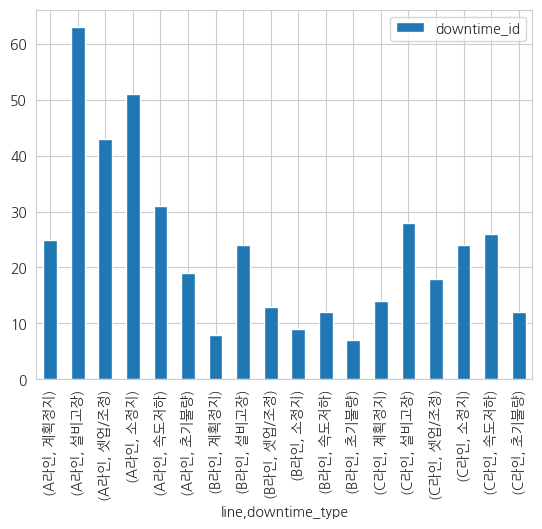

In [217]:
downtime_line1.plot(kind='bar')

In [218]:
downtime_line.reset_index(inplace=True)

In [219]:
downtime_line.columns=['line','cause','라인별 고장원인 건수']

In [221]:
line_failure=downtime_line.groupby(['line','cause']).size().unstack()

In [223]:
line_failure

cause,공구 교체,공구 마모,공구 파손,교육/미팅,금형 교체,금형 예열,냉각 부족,냉각수 부족,모터 과열,베어링 마모,...,자재 대기,전기 접촉 불량,절삭유 노후,점검,지그 교체,첫 로트 조건 미달,측정 오차,칩 막힘,프로그램 미최적화,프로그램 변경
line,,,,,,,,,,,,,,,,,,,,,
A라인,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
B라인,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
C라인,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


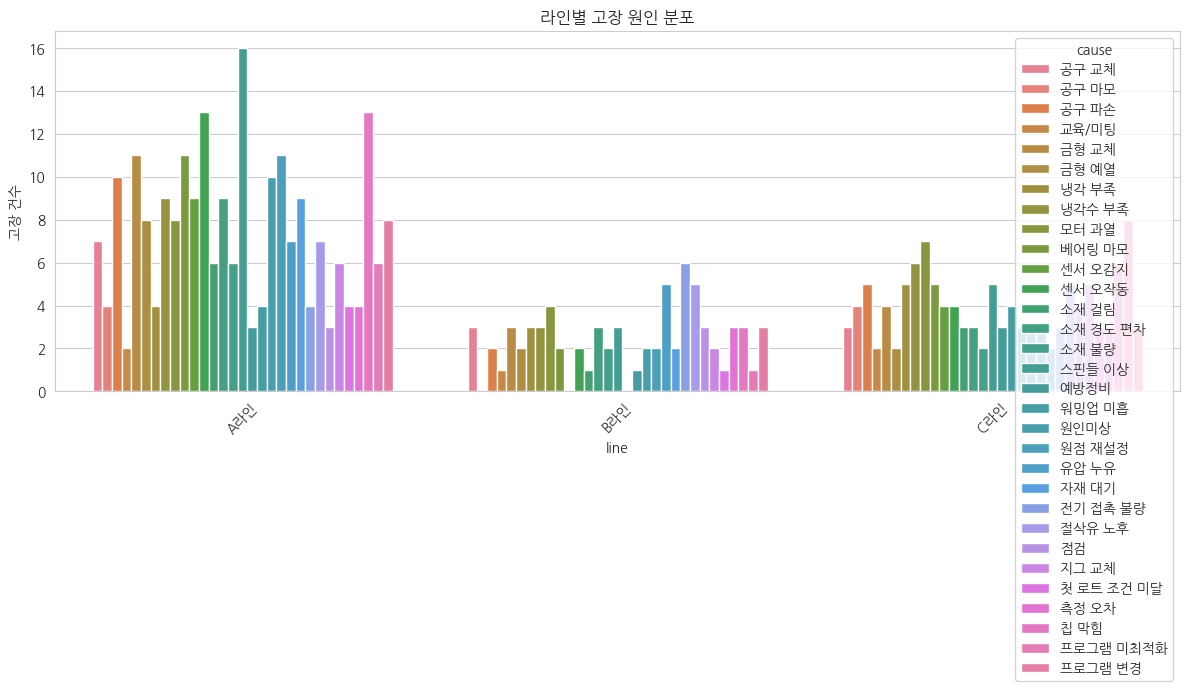

In [135]:
plt.figure(figsize=(12, 6))
sns.barplot(data=downtime_line, x='line', y='라인별 고장원인 건수', hue='cause')
plt.title('라인별 고장 원인 분포')
plt.ylabel('고장 건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Part 5: 경영진 보고용 대시보드 (15점)

지금까지 분석한 내용을 **한 페이지 대시보드**로 정리합니다.  
경영진은 숫자보다 **시각적 요약**을 선호합니다.

> **현업 포인트**: 대시보드는 '예쁘게' 만드는 것이 아니라  
> '의사결정에 필요한 정보'를 빠르게 전달하는 것이 목표입니다.

### 문제 5-1: 종합 대시보드 (15점)

`plt.subplot()` 또는 `fig.add_subplot()`을 사용하여 **2행 3열 (6개 패널)** 대시보드를 만드세요.  
Figure 크기: (20, 12)

**패널 구성:**

| 위치 | 차트 | 내용 |
|------|------|------|
| (1,1) | 라인 차트 | 월별 OEE 추이 (라인별, 3월 개선 활동 표시) |
| (1,2) | 수평 바 차트 | 설비별 OEE 랭킹 (색상으로 등급 표시) |
| (1,3) | 히트맵 | 라인 × 월 OEE 매트릭스 |
| (2,1) | 파이 차트 | 비가동 유형별 비율 |
| (2,2) | 그룹 바 차트 | 교대조별 OEE 3요소 비교 |
| (2,3) | 박스플롯 | 라인별 불량률 분포 |

**스타일 요구사항:**
- 전체 제목: '한국정밀산업(주) 생산 효율 대시보드 (2024년 상반기)'
- 각 패널에 소제목 포함
- `plt.tight_layout()` 적용
- 필요시 OEE 등급 색상 기준: 85% 이상(녹색), 70~85%(노란색), 70% 미만(빨간색)

In [144]:
equipment_OEE

,availability,performance,quality,OEE
equipment_id,,,,
EQ-B02,0.877976,0.952396,0.989244,0.8274
EQ-B04,0.88342,0.941311,0.992040,0.825046
EQ-B01,0.876626,0.949256,0.988051,0.822355
EQ-B03,0.877421,0.953664,0.979067,0.819432
EQ-C02,0.83689,0.913282,0.985817,0.753798
EQ-C01,0.831759,0.916553,0.985037,0.750914
EQ-C04,0.8316,0.911705,0.989775,0.750488
EQ-C03,0.825974,0.916041,0.972363,0.735935
EQ-A04,0.789697,0.88787,0.987322,0.692648


In [167]:
downtime_summary

,downtime_type,건수,총 시간(분),평균 시간(분),누적시간,누적비율(%)
1,설비고장,115,15182.017544,132.017544,15182.017544,52.779064
4,속도저하,69,4906.102941,71.102941,20088.120485,69.834737
0,계획정지,47,3887.717391,82.717391,23975.837876,83.350074
2,셋업/조정,74,2726.000000,36.837838,26701.837876,92.826794
5,초기불량,38,1033.388889,27.194444,27735.226765,96.419288
3,소정지,84,1030.000000,12.261905,28765.226765,100.000000


,defect_rate
line,
A라인,2.180824
B라인,1.283109
C라인,1.686549


In [ ]:
prod

Text(0.5, 1.0, '라인별 불량률 분포')

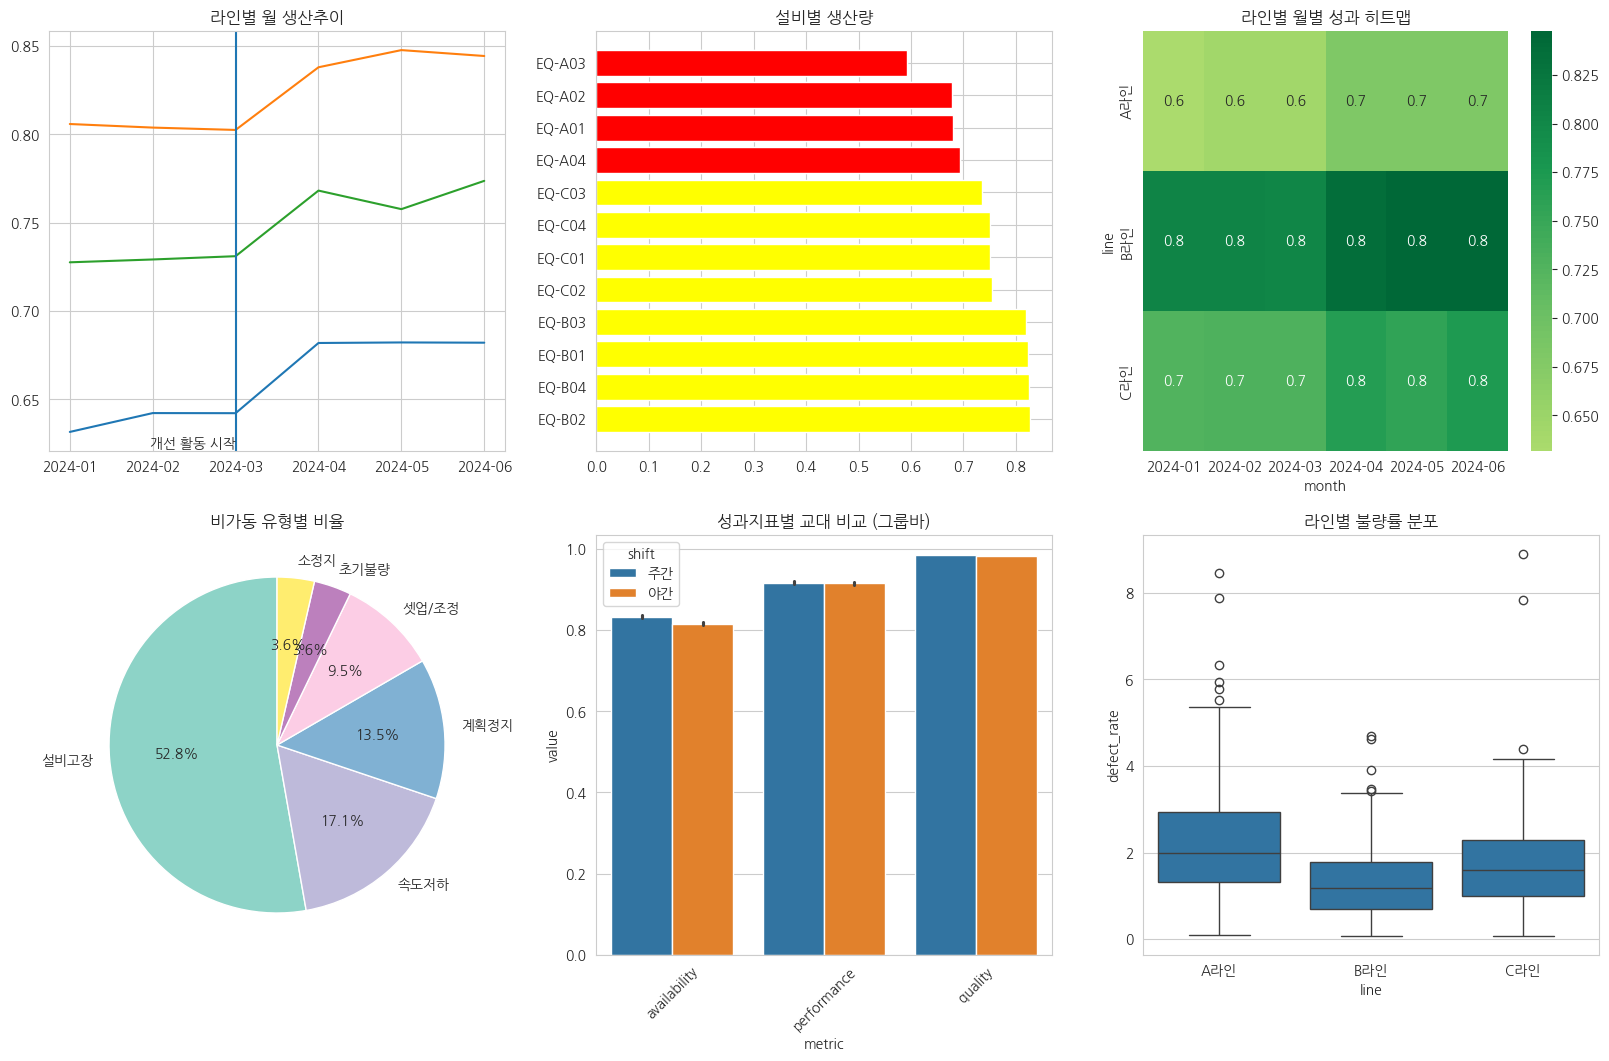

In [189]:
# 여기에 코드 작성
fig=plt.figure(figsize=(20, 12))

ax1 = fig.add_subplot(2, 3, 1)  # 3행2열의 1번

ax1.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['A라인',:],)
ax1.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['B라인',:],)
ax1.plot(l_m_pivot.columns.astype(str),l_m_pivot.loc['C라인',:],)
ax1.axvline(x='2024-03')
ax1.text(
    '2024-03',
    plt.ylim()[0],
    '개선 활동 시작',
    rotation=0,
    va='bottom',
    ha='right'
)
plt.title('라인별 월 생산추이')



ax2 = fig.add_subplot(2, 3, 2)  # 3행2열의 2번

ax2.barh((equipment_OEE[equipment_OEE['OEE']>=0.85]).index,equipment_OEE[equipment_OEE['OEE']>=0.85]['OEE'], color ='green')
ax2.barh((equipment_OEE[(equipment_OEE['OEE']<=0.85)|(equipment_OEE['OEE']>=0.7)]).index,equipment_OEE[(equipment_OEE['OEE']<=0.85)|(equipment_OEE['OEE']>=0.7)]['OEE'],color='yellow')
ax2.barh((equipment_OEE[equipment_OEE['OEE']<0.7]).index,equipment_OEE[equipment_OEE['OEE']<0.7]['OEE'],color='red')

plt.title('설비별 생산량')



ax3 = fig.add_subplot(2, 3, 3)  # 3행2열의 3번

sns.heatmap(data=l_m_pivot, annot=True, fmt='.1f', 
            cmap='RdYlGn', center=0.5, ax=ax3)
ax3.set_title('라인별 월별 성과 히트맵')



ax4 = fig.add_subplot(2, 3, 4)
values = downtime_summary['총 시간(분)'].values
labels = downtime_summary['downtime_type'].values

ax4.pie(values, labels=labels, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(labels))))
ax4.set_title('비가동 유형별 비율')





# 현재: x='shift', hue='metric' → 주간/야간 그룹
melted = pd.melt(prod_log[['shift','availability','performance','quality']], 
                 id_vars='shift', var_name='metric', value_name='value')

# 수정: x='metric', hue='shift' → 지표별 주간/야간 그룹
ax5 = fig.add_subplot(2, 3, 5)
sns.barplot(data=melted, x='metric', y='value', hue='shift', ax=ax5)
ax5.set_title('성과지표별 교대 비교 (그룹바)')
ax5.tick_params(axis='x', rotation=45)


ax6 = fig.add_subplot(2, 3, 6)  # 3행2열의 6번

sns.boxplot(data=prod_log,x='line',y='defect_rate')
ax6.set_title('라인별 불량률 분포')

In [185]:
melted.head(2)


,shift,metric,value
0,주간,availability,0.733125
1,주간,availability,0.839375


---
## 분석 결론 작성

분석 결과를 바탕으로, 아래 항목에 대해 **마크다운 셀에 직접** 작성하세요.

1. **현재 공장 OEE 수준**: World Class 기준 대비 현재 위치는?
2. **OEE를 끌어내리는 주요 요인**: 가동률/성능률/양품률 중 어느 것이 가장 문제인가?
3. **개선 활동 효과**: 3월 이후 실제로 OEE가 개선되었는가? 얼마나?
4. **라인별 차이**: A/B/C 라인 간 차이의 원인은?
5. **우선 개선 대상**: 가장 먼저 개선해야 할 설비 또는 로스 유형은?
6. **구체적 개선 제안**: 데이터에 근거한 3가지 이상의 개선 방안

### 분석 결론 (여기에 작성)

1. **현재 공장 OEE 수준**: 

2. **OEE를 끌어내리는 주요 요인**: 

3. **개선 활동 효과**: 

4. **라인별 차이**: 

5. **우선 개선 대상**: 

6. **구체적 개선 제안**: 


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 현장 데이터 결측치 확인 및 전처리
- [ ] IQR 기반 이상치 탐지
- [ ] 여러 테이블 Left Join 결합
- [ ] OEE 3요소(가동률·성능률·양품률) 직접 계산
- [ ] 설비별·라인별·월별 OEE 집계 및 비교
- [ ] 개선 전/후 효과 검증 (t-test)
- [ ] Six Big Losses 파레토 분석
- [ ] 이중 y축 차트, 히트맵, 파이 차트 등 다양한 시각화
- [ ] 6패널 종합 대시보드 구성
- [ ] 데이터 기반 개선 제안 도출